<a href="https://colab.research.google.com/github/jeromivj-git/Analyzing-E-Learning-Platform-Purchases-using-MySQL/blob/main/SoilNutrientAnalysis_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Soil Nutrient Analysis And Agricultural Insights using Python**


# **Objective**


* Analyze soil nutrient distribution across different geographical regions (States, Districts, Blocks, and Villages) to identify variations in soil health and fertility.

* Perform data cleaning, preprocessing, and exploratory data analysis (EDA) to ensure data quality and uncover meaningful patterns in soil nutrient levels.

* Examine the status of macro and micro nutrients (Low, Medium, High) to identify nutrient deficiencies and areas requiring soil improvement measures.

* Visualize nutrient trends and distributions across different years (2023–2025) and locations to support agricultural planning and decision-making.

* Generate actionable insights and recommendations for farmers, agricultural departments, and policymakers to promote balanced nutrient management and improve crop productivity.


# **Outcome**



The analysis identified the distribution of soil nutrient levels (Low, Medium, and High) across different States, Districts, Blocks, and Villages, helping to pinpoint nutrient-deficient and nutrient-rich regions. It revealed patterns in Macro and Micro nutrient categories, providing insights into soil fertility conditions across various geographical locations. Year-wise analysis from 2023 to 2025 highlighted trends and changes in soil nutrient status over time. The project generated actionable recommendations to support soil health management, optimize fertilizer usage, and improve agricultural productivity.


# **Domain**
Domain: Food and Agriculture

#**Dataset Information**

**Source:**
https://indiadataportal.com/p/soil-health-card/r/moafw-soil_health_card-vl-yr-abc</font></u>

**Year / Timeline:** 2023 - 2025

**Dataset Column/features Description:**

**id** – Unique identifier for each soil nutrient record in the dataset.

**year** – Financial or survey year in which the soil sample data was collected.

**state_name** – Name of the state where the soil sample was collected.

**state_code** – Numerical code assigned to the state.

**district_name** – Name of the district where the soil sample was collected.

**district_code** – Numerical code assigned to the district.

**block_name** – Name of the administrative block within the district where the soil sample was collected.

**block_code** – Numerical code assigned to the block.

**village_name** – Name of the village where the soil sample was collected.

**village_code** – Unique numerical code assigned to the village.

**nutrient_type** – Category of soil nutrient such as Macro or Micro nutrients.

**nutrient_name** – Name of the nutrient or soil property being analyzed.

**nutrient_level** – Status or classification of the nutrient in soil such as Low, Medium, or High.

**value** – Numerical count or frequency representing soil observations for the corresponding nutrient level.



# **Initial EDA**






In [ ]:
import pandas as pd
import numpy as np
url="https://raw.githubusercontent.com/jeromivj-git/Soil_Nutrient_Analysis-Python/refs/heads/main/soil_5000.csv"
df=pd.read_csv(url)



In [ ]:
print("\nShape:\n",np.shape(df))



Shape:
 (5000, 14)


This dataset contains 5000 rows and 14 columns

In [ ]:
df.columns


Index(['id', 'year', 'state_name', 'state_code', 'district_name',
       'district_code', 'block_name', 'block_code', 'village_name',
       'village_code', 'nutrient_type', 'nutrient_name', 'nutrient_level',
       'value'],
      dtype='object')

In [ ]:
df.select_dtypes(include='number').columns

Index(['id', 'state_code', 'district_code', 'block_code', 'village_code',
       'value'],
      dtype='object')

 Numerical columns mainly represents statecode,districtcode,block code,villagecode and value.

In [ ]:
df.select_dtypes(include='object').columns

Index(['year', 'state_name', 'district_name', 'block_name', 'village_name',
       'nutrient_type', 'nutrient_name', 'nutrient_level'],
      dtype='object')

 Categorical columns in this dataset represents name of states,districts,blocks,villages,nutrient type,level and it's name,

In [ ]:

df.head()




,id,year,state_name,state_code,district_name,district_code,block_name,block_code,village_name,village_code,nutrient_type,nutrient_name,nutrient_level,value
0,0,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Electrical Conductivity,Non Saline,15
1,1,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Electrical Conductivity,Saline,11
2,2,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Nitrogen,High,0
3,3,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Nitrogen,Low,2
4,4,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Nitrogen,Medium,24


In [ ]:
df.tail()

,id,year,state_name,state_code,district_name,district_code,block_name,block_code,village_name,village_code,nutrient_type,nutrient_name,nutrient_level,value
4995,4995,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Sankuparti,584135,Macro,Organic Carbon,Medium,0
4996,4996,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Sankuparti,584135,Macro,Phosphorus,High,0
4997,4997,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Sankuparti,584135,Macro,Phosphorus,Low,5
4998,4998,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Sankuparti,584135,Macro,Phosphorus,Medium,0
4999,4999,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Sankuparti,584135,Macro,Potassium,High,0


Examined the top 5 and bottom 5 records to perform a preliminary inspection of the dataset

In [ ]:
print("DataTypes:\n",df.dtypes)


DataTypes:
 id                 int64
year              object
state_name        object
state_code         int64
district_name     object
district_code      int64
block_name        object
block_code         int64
village_name      object
village_code       int64
nutrient_type     object
nutrient_name     object
nutrient_level    object
value              int64
dtype: object


#Interpretation
Statistical Interpretation of Observation Count

Mean (Average) = 3.45

On average, each nutrient observation record contains approximately 3.45 observations.
This indicates that the typical observation count across the dataset is relatively low.

Median = 1.00

The median observation count is 1, meaning that 50% of the records have an observation count of 1 or less.
Since the median is much lower than the mean, the distribution is not symmetrical.

Standard Deviation = 6.01

The standard deviation of 6.01 indicates substantial variability in observation counts across the dataset.
While many records have low observation counts, some records contain significantly higher values, causing the spread to increase.
Overall Insight
The observation count data is positively (right) skewed.
Most nutrient records have relatively low observation counts (around 1), while a smaller number of records have much higher counts.
The difference between the mean (3.45) and median (1.00), along with the relatively high standard deviation (6.01), suggests the presence of high-value observations that influence the average.
This pattern indicates that nutrient observations are not evenly distributed across all records, with certain nutrients or locations contributing disproportionately higher observation counts.


The average observation count is 3.45, while the median is only 1. This indicates a right-skewed distribution where most records have low observation counts and a few records have much higher values. The standard deviation of 6.01 confirms considerable variation in observation counts across the dataset.

In [ ]:
print("\nInformation:\n")
df.info()


Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              5000 non-null   int64 
 1   year            5000 non-null   object
 2   state_name      5000 non-null   object
 3   state_code      5000 non-null   int64 
 4   district_name   5000 non-null   object
 5   district_code   5000 non-null   int64 
 6   block_name      5000 non-null   object
 7   block_code      5000 non-null   int64 
 8   village_name    5000 non-null   object
 9   village_code    5000 non-null   int64 
 10  nutrient_type   5000 non-null   object
 11  nutrient_name   5000 non-null   object
 12  nutrient_level  5000 non-null   object
 13  value           5000 non-null   int64 
dtypes: int64(6), object(8)
memory usage: 547.0+ KB


### Key Insights

1. **The dataset contains 5,000 records and 14 features**, providing sufficient data for comprehensive soil nutrient analysis across multiple geographical regions.

2. **No missing values are present in the dataset**, indicating high data quality and minimizing the need for data cleaning or imputation.

3. **The dataset includes hierarchical geographical information** (State, District, Block, and Village), enabling detailed regional and location-based nutrient analysis.

4. **Nutrient-related attributes** (`nutrient_type`, `nutrient_name`, `nutrient_level`, and `value`) provide valuable information for assessing soil health and identifying nutrient deficiencies.
.


In [ ]:
df.size

70000

In [ ]:
df['year'].unique()

array(['2023-24'], dtype=object)

The dataset contains a total of 70000 data elements

In [ ]:
df['state_name'].unique()

array(['Andaman And Nicobar Islands', 'Andhra Pradesh'], dtype=object)

The dataset currently contains records from only 2 states/UTs: Andaman and Nicobar Islands and Andhra Pradesh.

In [ ]:
df['state_name'].nunique()

2

In [ ]:
df['nutrient_name'].unique()

array(['Electrical Conductivity', 'Nitrogen', 'Organic Carbon',
       'Phosphorus', 'Potassium', 'Soil Ph', 'Boron', 'Copper', 'Iron',
       'Manganese', 'Sulphur', 'Zinc'], dtype=object)

The dataset includes 12 soil parameters, covering both macronutrients (Nitrogen, Phosphorus, Potassium, Sulphur), micronutrients (Boron, Copper, Iron, Manganese, Zinc), and soil health indicators (pH, Organic Carbon, Electrical Conductivity).

In [ ]:
df['nutrient_name'].nunique()

12

In [ ]:
df['nutrient_type'].unique()


array(['Macro', 'Micro'], dtype=object)

The dataset classifies nutrients into two categories: Macro and Micro, indicating that both major and trace nutrient requirements of the soil are considered.

In [ ]:
df['nutrient_level'].unique()

array(['Non Saline', 'Saline', 'High', 'Low', 'Medium', 'Acidic',
       'Alkaline', 'Neutral', 'Deficient', 'Sufficient'], dtype=object)

The nutrient_level column contains 10 unique categories representing different soil conditions, including nutrient status (High, Medium, Low, Deficient, Sufficient), soil pH (Acidic, Neutral, Alkaline), and salinity levels (Saline, Non Saline).

In [ ]:
df['nutrient_level'].nunique()

10

## Column Renaming

In [ ]:
df.rename(columns={'value':'observation_count'},inplace=True)
df.head(1)


,id,year,state_name,state_code,district_name,district_code,block_name,block_code,village_name,village_code,nutrient_type,nutrient_name,nutrient_level,observation_count
0,0,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Electrical Conductivity,Non Saline,15


In [ ]:
df['observation_count'].unique()

array([15, 11,  0,  2, 24, 26,  9, 17, 12, 14,  4, 22,  7,  6,  3, 10,  8,
        1,  5, 13, 16, 44, 18, 23, 21, 32, 40, 29, 37, 30, 31, 28, 25, 20,
       27, 19])

#Statiscal Analysis

In [ ]:
mean_obs = df['observation_count'].mean()
median_obs = df['observation_count'].median()
std_obs = df['observation_count'].std()

print("Mean:", mean_obs)
print("Median:", median_obs)
print("Standard Deviation:", std_obs)

Mean: 3.4486
Median: 1.0
Standard Deviation: 6.009640687781752


#**Data Cleaning and Preprocessing**

## Checking Null Values





In [ ]:
print("\nNullChecks:\n",df.isnull())
print(df.isnull().sum())



NullChecks:
          id   year  state_name  state_code  district_name  district_code  \
0     False  False       False       False          False          False   
1     False  False       False       False          False          False   
2     False  False       False       False          False          False   
3     False  False       False       False          False          False   
4     False  False       False       False          False          False   
...     ...    ...         ...         ...            ...            ...   
4995  False  False       False       False          False          False   
4996  False  False       False       False          False          False   
4997  False  False       False       False          False          False   
4998  False  False       False       False          False          False   
4999  False  False       False       False          False          False   

      block_name  block_code  village_name  village_code  nutrient_type  

The dataset was analyzed for null values across all features. No missing values were present in any column; therefore, no imputation or deletion techniques were applied.

## Checking Duplicates


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated(subset=['state_code']).sum()

np.int64(4998)

The value column was renamed to observation_count as it is more meaningful and clearly represents the number of observations recorded for each nutrient level category

# Outliers Checking

In [ ]:
import pandas as pd
Q1=df['observation_count'].quantile(0.25)
Q3=df['observation_count'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['observation_count']<lower_bound)|(df['observation_count']>upper_bound)]
print("Number of outliers in observation_count",len(outliers))
outliers

Number of outliers in observation_count 367


,id,year,state_name,state_code,district_name,district_code,block_name,block_code,village_name,village_code,nutrient_type,nutrient_name,nutrient_level,observation_count
0,0,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Electrical Conductivity,Non Saline,15
4,4,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Nitrogen,Medium,24
6,6,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Organic Carbon,Low,26
10,10,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Phosphorus,Medium,17
13,13,2023-24,Andaman And Nicobar Islands,35,Nicobars,603,Campbell Bay,6498,Govinda Nagar,645199,Macro,Potassium,Medium,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4918,4918,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Regulapalem,584375,Micro,Boron,Deficient,18
4921,4921,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Regulapalem,584375,Micro,Copper,Sufficient,18
4922,4922,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Regulapalem,584375,Micro,Iron,Deficient,17
4925,4925,2023-24,Andhra Pradesh,28,Alluri Sitharama Raju,745,Ananthagiri,5584,Regulapalem,584375,Micro,Manganese,Sufficient,18


Outliers in the observation_count variable were identified using the IQR method. Since the values represent actual observation counts, outliers were retained unless found to be erroneous.

#Check skewness and apply transformations

In [ ]:
df['observation_count'].skew()


np.float64(2.9233140475019717)

The observation_count column has a skewness value of 2.92, indicating a highly positively skewed (right-skewed) distribution. Most observations have lower counts, while a few observations have very high counts.

In [ ]:
import numpy as np
df['observation_count_log']=np.log1p(df['observation_count'])
print(df['observation_count_log'].skew())

0.7597638584520927


After applying the log1p() transformation, the skewness of the observation_count column decreased from 2.92 to 0.76, indicating a significant reduction in positive skewness.

#Data type Checking

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     5000 non-null   int64  
 1   year                   5000 non-null   object 
 2   state_name             5000 non-null   object 
 3   state_code             5000 non-null   int64  
 4   district_name          5000 non-null   object 
 5   district_code          5000 non-null   int64  
 6   block_name             5000 non-null   object 
 7   block_code             5000 non-null   int64  
 8   village_name           5000 non-null   object 
 9   village_code           5000 non-null   int64  
 10  nutrient_type          5000 non-null   object 
 11  nutrient_name          5000 non-null   object 
 12  nutrient_level         5000 non-null   object 
 13  observation_count      5000 non-null   int64  
 14  observation_count_log  5000 non-null   float64
dtypes: f

No major datatype inconsistencies were found in the dataset. The existing data types were appropriate for analysis; therefore, no datatype conversion was required.

#Data type Conversion(To improve memory efficiency)

In [ ]:
categorical_cols = [

    'state_code',
    'district_code',
    'block_code',
    'village_code',
    'state_name',
    'district_name',
    'block_name',
    'village_name',
    'nutrient_type',
    'nutrient_name',
    'nutrient_level'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')
df.dtypes

,0
id,int64
year,object
state_name,category
state_code,category
district_name,category
district_code,category
block_name,category
block_code,category
village_name,category
village_code,category


#Droping Year Column

In [ ]:
df.drop(columns=['year'],inplace=True)

The year column was removed because it contained a single value (2023-24) across all records and therefore did not contribute any variability or analytical value to the dataset.

In [ ]:
df.dtypes

,0
id,int64
state_name,category
state_code,category
district_name,category
district_code,category
block_name,category
block_code,category
village_name,category
village_code,category
nutrient_type,category




> Converted all location-related fields, nutrient attributes column to the `category` data type, as they represent labels rather than numerical measurements. This reduces memory usage and improves the efficiency of grouping, filtering, and aggregation operations during analysis.


In [ ]:
df.groupby('nutrient_name')['nutrient_level'].unique()

/tmp/ipykernel_2142/2484815327.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('nutrient_name')['nutrient_level'].unique()


,nutrient_level
nutrient_name,
Boron,"['Deficient', 'Sufficient'] Categories (10, ob..."
Copper,"['Deficient', 'Sufficient'] Categories (10, ob..."
Electrical Conductivity,"['Non Saline', 'Saline'] Categories (10, objec..."
Iron,"['Deficient', 'Sufficient'] Categories (10, ob..."
Manganese,"['Deficient', 'Sufficient'] Categories (10, ob..."
Nitrogen,"['High', 'Low', 'Medium'] Categories (10, obje..."
Organic Carbon,"['High', 'Low', 'Medium'] Categories (10, obje..."
Phosphorus,"['High', 'Low', 'Medium'] Categories (10, obje..."
Potassium,"['High', 'Low', 'Medium'] Categories (10, obje..."


# Number of villages in each state

In [ ]:
df.groupby('state_name')['village_name'].nunique()

/tmp/ipykernel_2142/3314562549.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('state_name')['village_name'].nunique()


,village_name
state_name,
Andaman And Nicobar Islands,46
Andhra Pradesh,127


#Number of soil observations by state

In [ ]:
df.groupby('state_name')['observation_count'].sum()

/tmp/ipykernel_2142/3209733791.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('state_name')['observation_count'].sum()


,observation_count
state_name,
Andaman And Nicobar Islands,7248
Andhra Pradesh,9995


Interpretation:

 Andhra Pradesh has a higher total observation count (9,995) than Andaman And Nicobar Islands (7,248), indicating more soil samples were collected and analyzed there.


# Nutrient distribution by state

In [ ]:
pd.crosstab(df['state_name'],df['nutrient_name'])

nutrient_name,Boron,Copper,Electrical Conductivity,Iron,Manganese,Nitrogen,Organic Carbon,Phosphorus,Potassium,Soil Ph,Sulphur,Zinc
state_name,,,,,,,,,,,,
Andaman And Nicobar Islands,92,92,92,92,92,138,138,138,138,138,92,92
Andhra Pradesh,252,252,254,252,252,381,381,381,379,378,252,252


Interpretation:

*  The crosstab analysis reveals that Andhra Pradesh has a higher number of nutrient observations than Andaman and Nicobar Islands, indicating wider soil testing coverage.
*  Major nutrients such as Nitrogen, Phosphorus, Potassium, Organic Carbon, and Soil pH have the highest observation counts, suggesting they are prioritized in soil health assessment, while micronutrients have comparatively fewer observations.

In [ ]:
pd.crosstab(
    df['nutrient_name'],
    df['nutrient_level']
)

nutrient_level,Acidic,Alkaline,Deficient,High,Low,Medium,Neutral,Non Saline,Saline,Sufficient
nutrient_name,,,,,,,,,,
Boron,0,0,172,0,0,0,0,0,0,172
Copper,0,0,172,0,0,0,0,0,0,172
Electrical Conductivity,0,0,0,0,0,0,0,173,173,0
Iron,0,0,172,0,0,0,0,0,0,172
Manganese,0,0,172,0,0,0,0,0,0,172
Nitrogen,0,0,0,173,173,173,0,0,0,0
Organic Carbon,0,0,0,173,173,173,0,0,0,0
Phosphorus,0,0,0,173,173,173,0,0,0,0
Potassium,0,0,0,173,172,172,0,0,0,0


### Interpretation:
* **Nitrogen, Organic Carbon, Phosphorus, and Potassium** are distributed across **Low, Medium, and High** levels, indicating varying nutrient availability across the sampled soils.

* **Boron, Copper, Iron, Manganese, Sulphur, and Zinc** have equal counts in **Deficient** and **Sufficient** categories, suggesting these micronutrients are evaluated based on sufficiency thresholds rather than multiple concentration levels.

* **Soil pH** is evenly distributed among **Acidic, Neutral, and Alkaline** categories, indicating the dataset contains a diverse range of soil types.

* **Electrical Conductivity (EC)** has equal numbers of **Saline** and **Non-Saline** observations, showing a balanced representation of soils with and without salinity concerns.

* The nearly identical counts across categories (172–173 observations) suggest a well-structured dataset where nutrient measurements and classifications are consistently recorded across soil samples.


#state-wise nutrient-level distribution

In [ ]:
pd.crosstab(
    [df['state_name'], df['nutrient_name']],
    df['nutrient_level']
)

nutrient_level                                       Acidic  Alkaline  \
state_name                  nutrient_name                               
Andaman And Nicobar Islands Boron                         0         0   
                            Copper                        0         0   
                            Electrical Conductivity       0         0   
                            Iron                          0         0   
                            Manganese                     0         0   
                            Nitrogen                      0         0   
                            Organic Carbon                0         0   
                            Phosphorus                    0         0   
                            Potassium                     0         0   
                            Soil Ph                      46        46   
                            Sulphur                       0         0   
                            Zinc                          0         0   
Andhra Pradesh              Boron                         0         0   
                            Copper                        0         0   
                            Electrical Conductivity       0         0   
                            Iron                          0         0   
                            Manganese                     0         0   
                            Nitrogen                      0         0   
                            Organic Carbon                0         0   
                            Phosphorus                    0         0   
                            Potassium                     0         0   
                            Soil Ph                     126       126   
                            Sulphur                       0         0   
                            Zinc                          0         0   

nutrient_level                                       Deficient  High  Low  \
state_name                  nutrient_name                                   
Andaman And Nicobar Islands Boron                           46     0    0   
                            Copper                          46     0    0   
                            Electrical Conductivity          0     0    0   
                            Iron                            46     0    0   
                            Manganese                       46     0    0   
                            Nitrogen                         0    46   46   
                            Organic Carbon                   0    46   46   
                            Phosphorus                       0    46   46   
                            Potassium                        0    46   46   
                            Soil Ph                          0     0    0   
                            Sulphur                         46     0    0   
                            Zinc                            46     0    0   
Andhra Pradesh              Boron                          126     0    0   
                            Copper                         126     0    0   
                            Electrical Conductivity          0     0    0   
                            Iron                           126     0    0   
                            Manganese                      126     0    0   
                            Nitrogen                         0   127  127   
                            Organic Carbon                   0   127  127   
                            Phosphorus                       0   127  127   
                            Potassium                        0   127  126   
                            Soil Ph                          0     0    0   
                            Sulphur                        126     0    0   
                            Zinc                           126     0    0   

nutrient_level                                       Medium  Neutral  \
state_name                

Interpretation:



* **Nitrogen, Organic Carbon, Phosphorus, and Potassium** show observations across **Low, Medium, and High** categories in both states, indicating variability in major nutrient availability.

* **Boron, Copper, Iron, Manganese, Sulphur, and Zinc** are classified only as **Deficient** or **Sufficient**, suggesting these micronutrients are assessed using a binary sufficiency approach.

* **Soil pH** is categorized as **Acidic, Neutral, and Alkaline**, reflecting the chemical nature of the soil rather than nutrient concentration.

* **Electrical Conductivity (EC)** is classified as **Saline** or **Non-Saline**, helping identify potential soil salinity issues affecting crop growth.

* Andhra Pradesh consistently has higher observation counts than Andaman And Nicobar Islands across all nutrient categories, indicating broader soil testing coverage and a larger dataset for analysis.


 # EDA and Visualizations

#Univariate Analysis


#1.Count Plot – Distribution of Nutrient Types

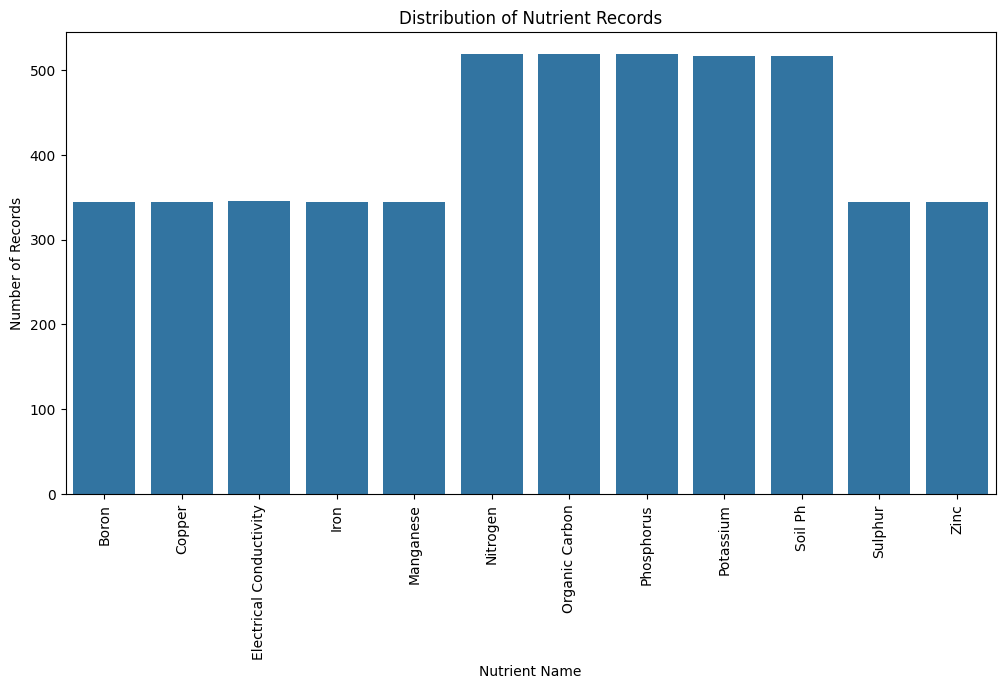

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.countplot(data=df, x='nutrient_name')

plt.xticks(rotation=90)
plt.title("Distribution of Nutrient Records")
plt.xlabel("Nutrient Name")
plt.ylabel("Number of Records")

plt.show()

Interpretation:

->Nitrogen, Organic Carbon, Phosphorus, Potassium, and Soil pH have the highest density

->Boron, Copper, Iron, Manganese, Sulphur, Zinc, and Electrical Conductivity share an identical lower count

#2.Histogram – Distribution of Soil Sample Counts

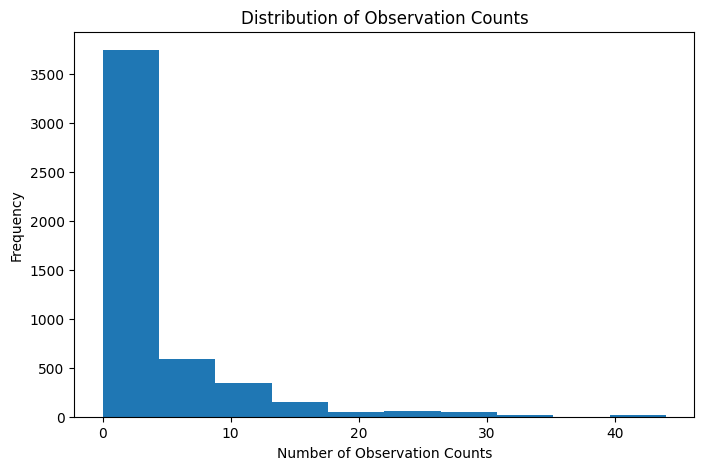

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['observation_count'], bins=10)

plt.title("Distribution of Observation Counts")
plt.xlabel("Number of Observation Counts")
plt.ylabel("Frequency")

plt.show()

Interpretation:



* Most observation counts are between 0 and 5, indicating that most nutrient observations have relatively low recorded counts.
* The distribution is right-skewed, with a small number of observations having much higher counts (up to 44).
* A few records have unusually high observation counts, creating outliers in the dataset.
* Observation counts are not evenly distributed, as the majority of records are concentrated at lower values.
* Higher observation counts occur less frequently, indicating that only a small subset of nutrient observations have large counts.
Business Interpretation
* Nutrient observations vary considerably across locations, suggesting differences in nutrient occurrence and soil conditions.
* Locations with higher observation counts may require further investigation to understand nutrient concentration patterns and soil fertility status.
* The presence of outliers indicates that some nutrients or locations exhibit substantially different observation patterns than the majority of samples.
* Agricultural planners should focus on nutrient deficiency trends and district-level variations rather than relying solely on average observation count.

#3.Box Plot – Detect Outliers

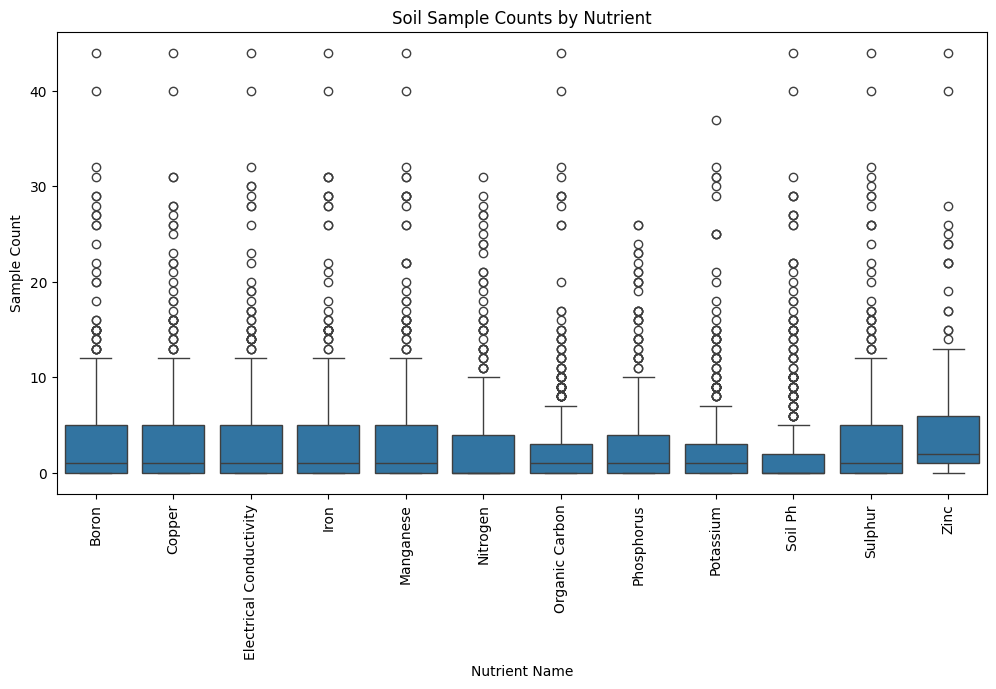

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='nutrient_name', y='observation_count')

plt.xticks(rotation=90)
plt.title("Soil Sample Counts by Nutrient")
plt.xlabel("Nutrient Name")
plt.ylabel("Sample Count")

plt.show()


Interpretation:


* Low medians (under 5 samples) across all nutrients indicate that the average customer only runs highly localized, bare-minimum testing per field.

* Extreme vertical outliers (30 to 44 samples) pinpoint a distinct, high-value segment of corporate farms performing intense, high-density grid-sampling.

* The identical outlier structures across micronutrients (Boron, Copper, Iron) confirm that enterprise clients purchase the absolute full-spectrum testing suite.
* Zinc shows a slightly elevated baseline and median compared to other micronutrients, highlighting its commercial perception as a high-priority asset.



# Bivariate Analysis

#1. Bar Plot – Nutrient Level Analysis

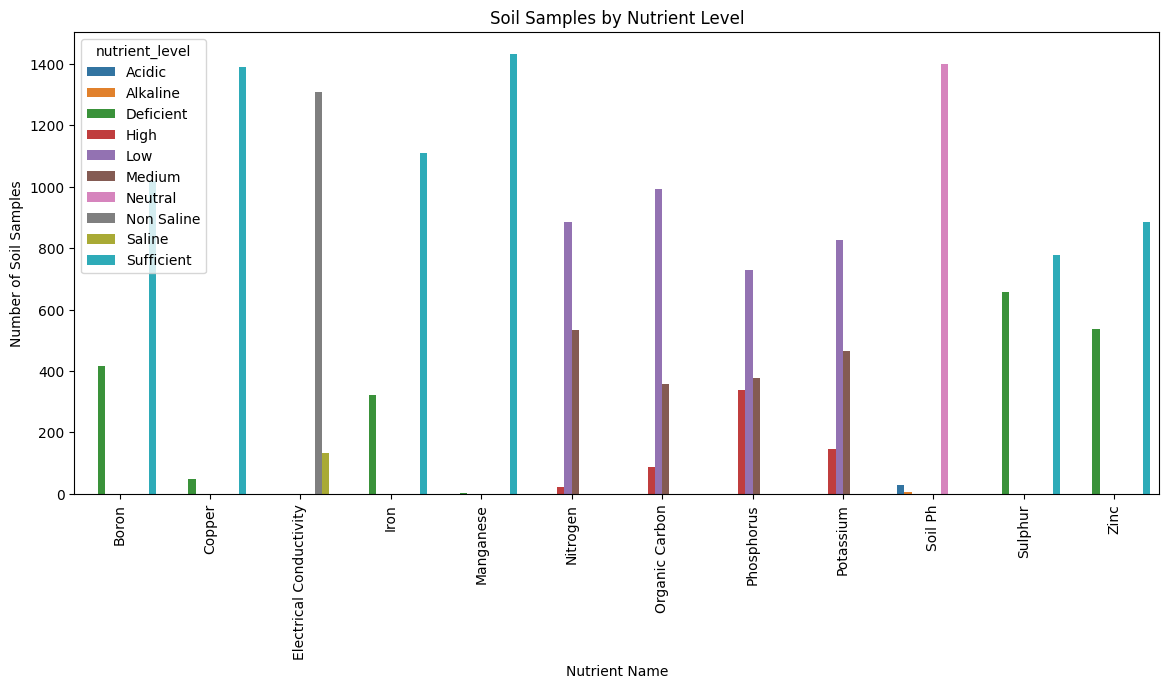

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=df,
    x='nutrient_name',
    y='observation_count',
    hue='nutrient_level',
    estimator=sum,errorbar=None
)

plt.xticks(rotation=90)
plt.title("Soil Samples by Nutrient Level")
plt.xlabel("Nutrient Name")
plt.ylabel("Number of Soil Samples")

plt.show()

Interpretation:


* Massive spikes in "Low" and "Medium" levels for Nitrogen, Potassium, and Carbon represent an immediate, high-volume commercial demand for standard bulk fertilizers.
* High rates of "Deficient" Boron, Iron, Sulphur, and Zinc signal a lucrative market for specialized, high-margin secondary soil treatments.
* Copper and Manganese are overwhelmingly "Sufficient," meaning fertilizer blenders should avoid wasting resources or adding costs by over-allocating these elements.
*The strong cluster around "Neutral" pH proves that the regional land is highly receptive to nutrient applications without requiring costly lime treatments.
* Electrical Conductivity is heavily "Non Saline," giving agribusinesses confidence to invest heavily in standard crop nutrition programs without fear of salt-induced crop failure.


#2. District-wise Nutrient Analysis Heatmap

/tmp/ipykernel_2142/2851831432.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


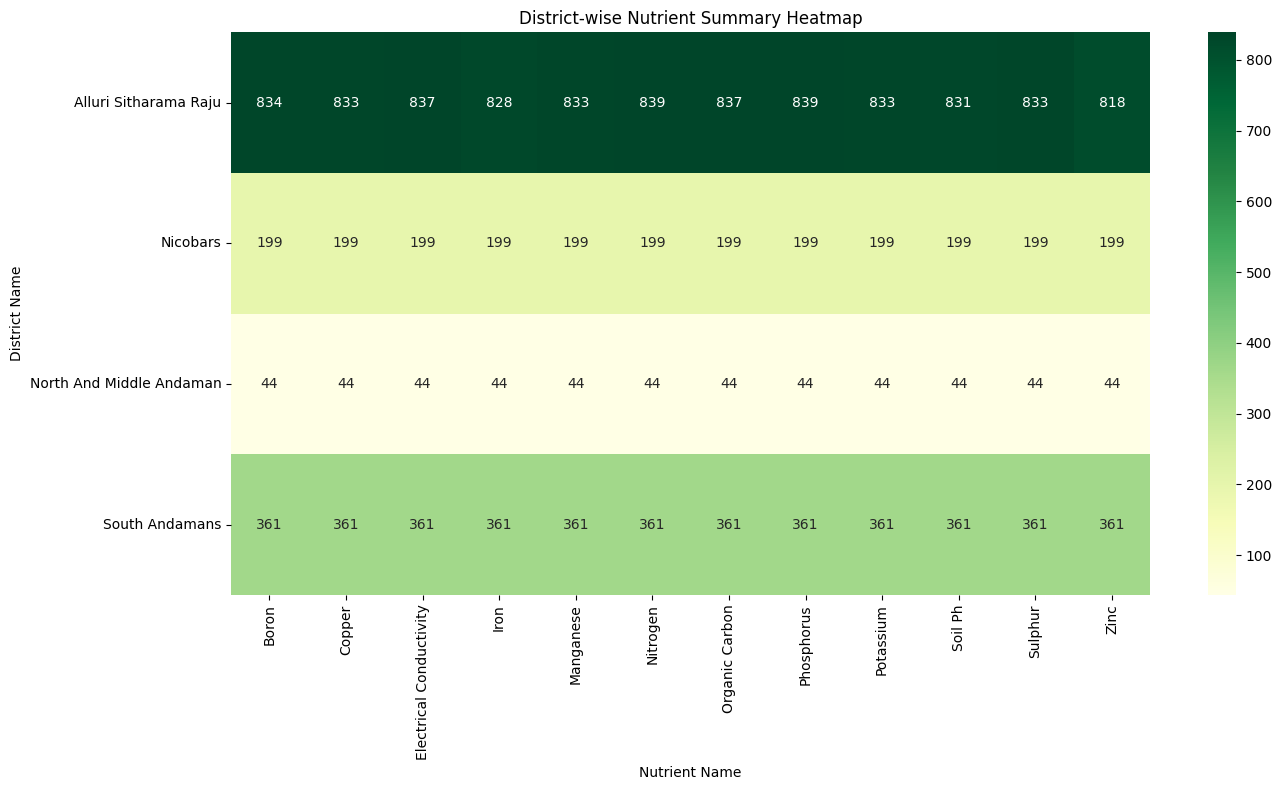

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pivot_table = df.pivot_table(
    index='district_name',
    columns='nutrient_name',
    values='observation_count',
    aggfunc='sum'
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_table,
    cmap='YlGn',
    annot=True,
    fmt='.0f'
)

plt.title('District-wise Nutrient Summary Heatmap')
plt.xlabel('Nutrient Name')
plt.ylabel('District Name')

plt.tight_layout()
plt.show()

#3.Heatmap – Nutrient Counts Across Villages

/tmp/ipykernel_2142/909941805.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_level = df.pivot_table(


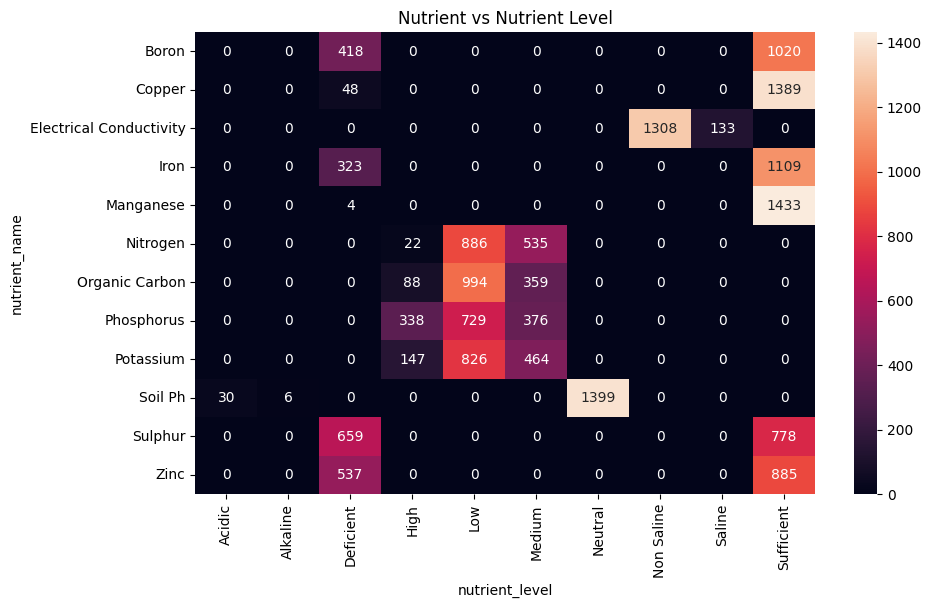

In [ ]:
pivot_level = df.pivot_table(
    index='nutrient_name',
    columns='nutrient_level',
    values='observation_count',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_level, annot=True, fmt='.0f')
plt.title("Nutrient vs Nutrient Level")
plt.show()

Interpretation:


* Massive NPK & Carbon Deficit: Over 700 to 900+ samples show critically "Low" Nitrogen, Organic Carbon, Phosphorus, and Potassium, pointing to a huge, ready market for standard bulk fertilizers and organic matter.
* High-Margin Micronutrient Opportunities: Large volumes of Deficient Sulphur (659), Zinc (537), and Boron (418) represent immediate upselling potential for high-margin, specialized micronutrient additives.
* Oversupply Protection for Copper & Manganese: With nearly 1,400 samples showing "Sufficient" levels for Copper and Manganese, input suppliers can avoid wasting inventory or over-formulating products with these elements.




#Correlation heatmap of nutrients

/tmp/ipykernel_2142/771084260.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = df.pivot_table(


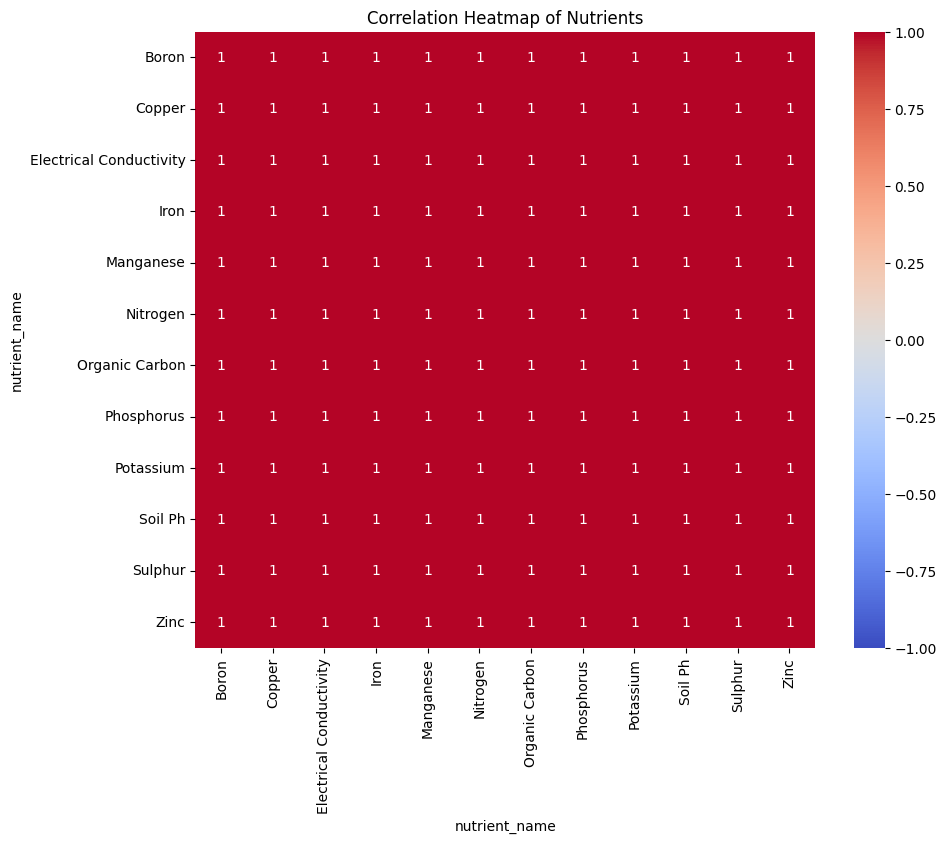

In [ ]:
pivot_df = df.pivot_table(
    index='village_code',
    columns='nutrient_name',
    values='observation_count',
    aggfunc='sum'
)

corr = pivot_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Nutrients")
plt.show()

Interpretation:
The correlation heatmap was generated using aggregated nutrient sample counts at the village level. The correlations represent similarities in nutrient sample distributions across villages rather than direct relationships between nutrient concentrations.

#3. Multivariate Analysis

#Grouped Analysis

In [ ]:
grouped = df.groupby(
    ['nutrient_name', 'nutrient_level']
)['observation_count'].sum().reset_index()

print(grouped.head())

  nutrient_name nutrient_level  observation_count
0         Boron         Acidic                  0
1         Boron       Alkaline                  0
2         Boron      Deficient                418
3         Boron           High                  0
4         Boron            Low                  0


/tmp/ipykernel_2142/3207331429.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(


Interpretation:
Based on the values shown:

1. Boron deficiency is observed in 418 soil samples, while 1020 samples are Boron sufficient, indicating generally adequate Boron availability.
2. Copper deficiency is very low (48 samples), whereas 1389 samples are Copper sufficient, suggesting Copper is sufficient in most soils.
3. Electrical Conductivity data shows 1308 samples are classified as Non-Saline, indicating salinity is not a major concern in the study area.
4. The number of sufficient samples is significantly higher than deficient samples for both Boron and Copper.
5. Overall, the soil samples exhibit favorable micronutrient status and low salinity risk, reflecting relatively healthy soil conditions.


#Pivot Table

In [ ]:
pivot_table = df.pivot_table(
    index='district_name',
    columns='nutrient_name',
    values='observation_count',
    aggfunc='sum'
)

print(pivot_table.head())

nutrient_name             Boron  Copper  Electrical Conductivity  Iron  \
district_name                                                            
Alluri Sitharama Raju       834     833                      837   828   
Nicobars                    199     199                      199   199   
North And Middle Andaman     44      44                       44    44   
South Andamans              361     361                      361   361   

nutrient_name             Manganese  Nitrogen  Organic Carbon  Phosphorus  \
district_name                                                               
Alluri Sitharama Raju           833       839             837         839   
Nicobars                        199       199             199         199   
North And Middle Andaman         44        44              44          44   
South Andamans                  361       361             361         361   

nutrient_name             Potassium  Soil Ph  Sulphur  Zinc  
district_name                 

/tmp/ipykernel_2142/1613323327.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


Interpretation:


1. **Alluri Sitharama Raju district has the largest volume of soil test records**, indicating a higher demand for soil health monitoring and agricultural advisory services in this region.

2. **Nitrogen, Phosphorus, Potassium, and micronutrients have been tested consistently across districts**, suggesting standardized soil testing programs and reliable data coverage.

3. **Nicobars and South Andamans show moderate testing activity**, presenting opportunities for expanding soil testing awareness and agricultural support services.

4. **North And Middle Andaman has comparatively fewer soil samples**, indicating a potential need for increased soil testing campaigns and farmer outreach programs.

5. **The availability of comprehensive nutrient data across districts can help agricultural businesses, fertilizer suppliers, and policymakers make targeted nutrient management and resource allocation decisions.**



#Stacked Bar Chart

/tmp/ipykernel_2142/2201512456.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


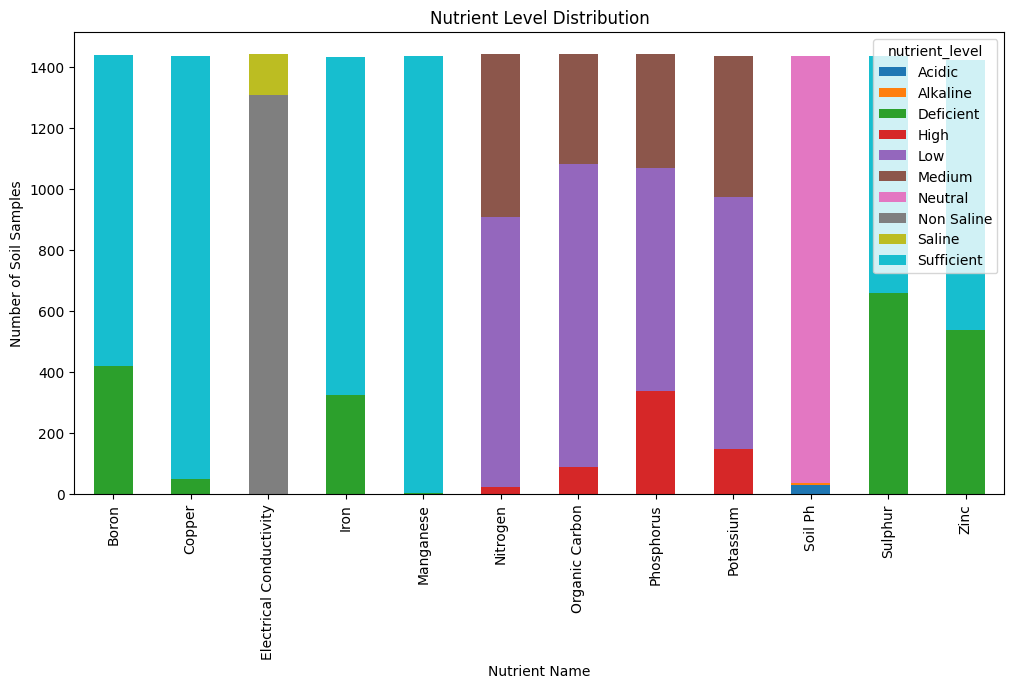

In [ ]:
pivot = df.pivot_table(
    index='nutrient_name',
    columns='nutrient_level',
    values='observation_count',
    aggfunc='sum'
)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Nutrient Level Distribution")
plt.xlabel("Nutrient Name")
plt.ylabel("Number of Soil Samples")

plt.show()

Interpretation:


*  Nitrogen, Organic Carbon, Phosphorus, and Potassium are overwhelmingly "Low" or "Medium," securing massive, predictable demand for standard bulk NPK fertilizer blends.
*  Sulphur and Zinc exhibit the highest absolute deficiency rates, making them your most lucrative targets for high-margin, specialized crop-nutrition additions.
* Copper and Manganese are almost entirely "Sufficient," meaning product formulators can exclude them from regional blends to cut production costs and protect profit margins.
* The widespread dominance of Neutral pH and Non-Saline conductivity indicates highly stable soils, giving farmers the safety margin needed to invest confidently in premium inputs.



# Export to csv file

In [ ]:
df.to_csv('soil_analysis.csv',index=False)

#Download csv file

In [ ]:
from google.colab import files
files.download('soil_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#DASH BOARD

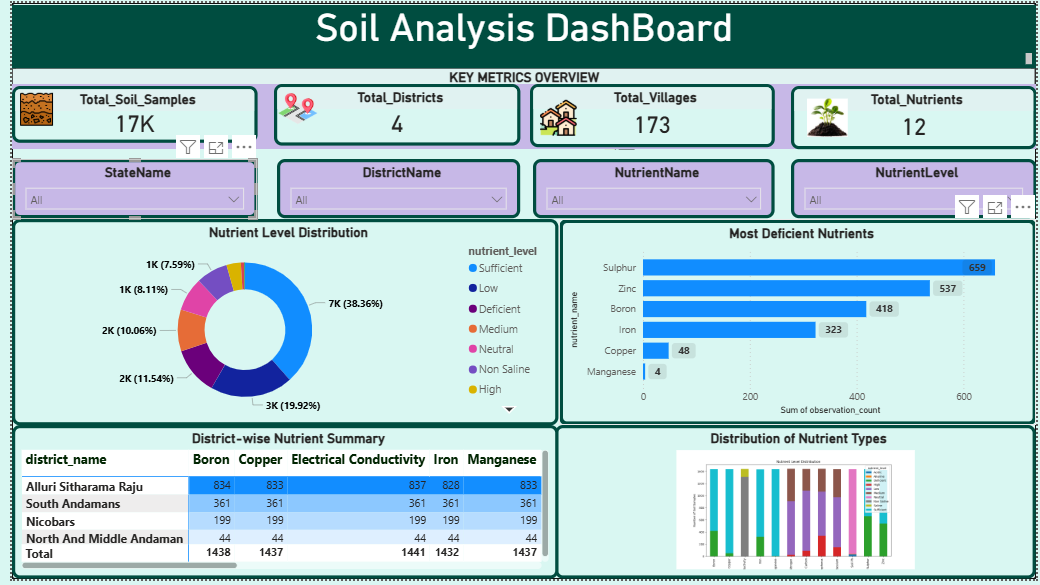

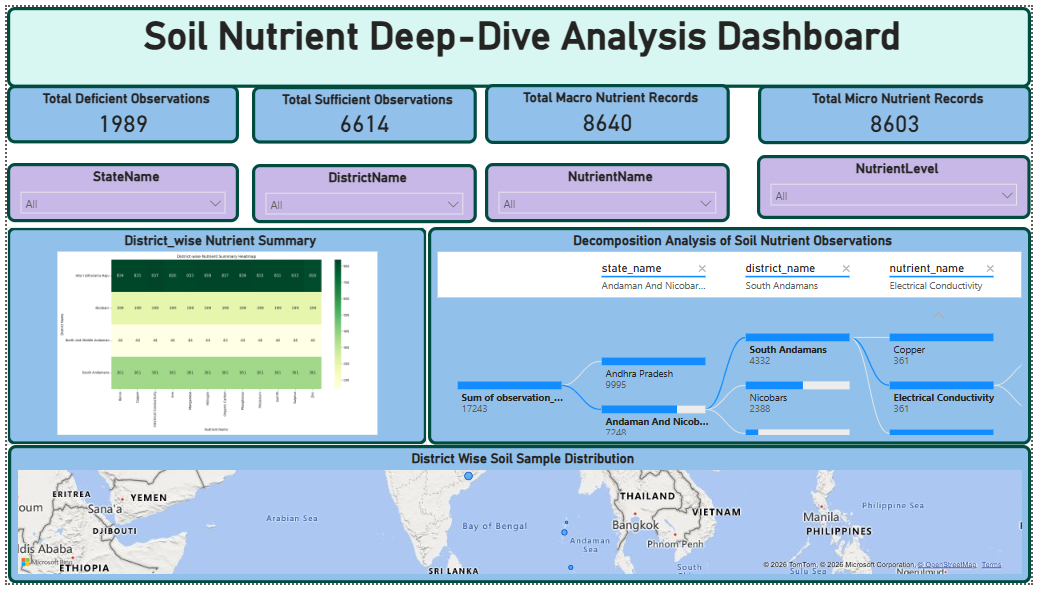

#DOCUMENTATION

https://drive.google.com/file/d/1NbcxYxlbPaXmqsPbH4NTIedT4r33YHKv/view?usp=sharing

#PRESENTATION

https://docs.google.com/presentation/d/1VrZq0cbuVgUn6q3rE8QyIhS9HlHOtzTZ/edit?usp=sharing&ouid=115727835928550270830&rtpof=true&sd=true

## Final Overall Insights:

*	Total soil samples were collected from multiple districts and villages, providing broad geographical coverage for analysis.
*	The dashboard revealed the distribution of nutrient levels across the dataset, including Deficient, Low, Medium, High, and Sufficient categories.
*	Soil nutrient status varied significantly across locations, indicating differences in soil fertility conditions.
*	Certain nutrients showed higher deficiency levels than others, highlighting specific nutrient management challenges.
*	District-wise analysis indicated that nutrient deficiencies are not uniformly distributed across all regions.
*	The decomposition analysis helped identify the contribution of location, nutrient type, and nutrient status to overall soil observations.
*	Historical nutrient status patterns suggest that some regions may continue to experience nutrient deficiencies if corrective actions are not implemented.
*	The dashboard establishes a foundation for future forecasting of nutrient trends and fertilizer requirements.
________________________________________


# Future Enhancement

*	Integrate machine learning models to predict future nutrient deficiencies based on historical soil data.
*	Develop district-wise fertilizer recommendation systems based on nutrient deficiency patterns.
*	Incorporate weather, rainfall, and crop data to improve soil health analysis and forecasting accuracy.
*	Enable real-time data integration from soil testing laboratories and agricultural agencies.
*	Build a farmer-focused decision support system with automated recommendations and alerts.


# Conclusion

* The Soil Nutrient Analysis Dashboard successfully transformed raw soil testing data into meaningful and actionable insights.
* Interactive Power BI visualizations enabled efficient exploration of nutrient conditions across districts, villages, and nutrient categories.
* The analysis identified key nutrient deficiencies and highlighted areas requiring targeted soil management practices.
* The dashboard supports data-driven agricultural decision-making by providing a clear view of soil fertility status.
* Overall, the project demonstrates how data analytics and visualization can contribute to improved soil health management, optimized fertilizer usage, and enhanced agricultural productivity.
